# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings.parquet') LIMIT 5").df()

,SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,QueryUTC,SensorReadingUTC_SecondsFromPrior
0,1699230622,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.889999,NaN,<NA>,<NA>
1,1699231222,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.839996,NaN,<NA>,600
2,1699231822,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.849998,NaN,<NA>,600
3,1699232422,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.849998,NaN,<NA>,600
4,1699233022,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.889999,NaN,<NA>,600


In [2]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings.parquet') LIMIT 5").df()

,DeviceID,DeviceName,SensorReadingUTC,QueryUTC,SensorReadingF,SensorReadingRh
0,coris:12162,Peabody TH-L Mammal Hall D444,1699230622,<NA>,69.889999,NaN
1,coris:12162,Peabody TH-L Mammal Hall D444,1699231222,<NA>,69.839996,NaN
2,coris:12162,Peabody TH-L Mammal Hall D444,1699231822,<NA>,69.849998,NaN
3,coris:12162,Peabody TH-L Mammal Hall D444,1699232422,<NA>,69.849998,NaN
4,coris:12162,Peabody TH-L Mammal Hall D444,1699233022,<NA>,69.889999,NaN


In [3]:
duckdb.sql("SELECT * FROM read_parquet('data/sensors.parquet') LIMIT 5").df()

,SensorID,SensorName,SensorType,DeviceID,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,hobolink:10740550-10740550-2,ICSC__010C149________RH,RH,hobolink:10740550,RH,FLOATER,Unknown,FLOATER,None
1,hobolink:10740550-10740550-1,ICSC__010C149________Temperature,Temperature,hobolink:10740550,Temperature,FLOATER,Unknown,FLOATER,None
2,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
3,coris:21377,Temp KGL 21_D0B2,Temperature,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
4,hobolink:22202142-22179174-2,RX Station 1_RH,RH,hobolink:22202142,RH,Station,Unknown,1,Not Indicated


In [4]:
duckdb.sql("SELECT * FROM read_parquet('data/devices.parquet') LIMIT 5").df()

,DeviceID,DeviceName,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,hobolink:10740550,ICSC__010C149_______,Temperature,FLOATER,Unknown,FLOATER,None
1,coris:12167,Peabody TH-L Upper Great Hall D0B2,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
2,hobolink:22202142,RX Station 1,Temperature,Station,Unknown,1,Not Indicated
3,hobolink:22202141,RX Station 2,Temperature,Station,Unknown,2,Not Indicated
4,coris:12162,Peabody TH-L Mammal Hall D444,D444,YPM,Yale Peabody Museum,104,Not Indicated


In [5]:
duckdb.sql("SELECT * FROM read_parquet('data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1699230622,2023-11-05 17:30:22,2023-11-05 10:30:22-07:00,2023-11-05,12:30:22,2023,11,Sunday,7,12,0,PM
1,1699231222,2023-11-05 17:40:22,2023-11-05 10:40:22-07:00,2023-11-05,12:40:22,2023,11,Sunday,7,12,0,PM
2,1699231822,2023-11-05 17:50:22,2023-11-05 10:50:22-07:00,2023-11-05,12:50:22,2023,11,Sunday,7,12,0,PM
3,1699232422,2023-11-05 18:00:22,2023-11-05 11:00:22-07:00,2023-11-05,13:00:22,2023,11,Sunday,7,13,1,PM
4,1699233022,2023-11-05 18:10:22,2023-11-05 11:10:22-07:00,2023-11-05,13:10:22,2023,11,Sunday,7,13,1,PM


In [6]:
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings_daily.parquet') LIMIT 5").df()

,date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,2025-11-04,coris:21373,1,68.300003,0.000000,68.300003,NaN,68.300003,NaN
1,2025-11-04,coris:21374,1,0.000000,53.970001,NaN,53.970001,NaN,53.970001
2,2025-11-04,coris:21377,1,71.099998,0.000000,71.099998,NaN,71.099998,NaN
3,2025-11-04,coris:21378,1,0.000000,42.689999,NaN,42.689999,NaN,42.689999
4,2025-11-04,hobolink:10740550-10740550-1,1,67.370972,0.000000,67.370972,NaN,67.370972,NaN


In [7]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings_daily.parquet') LIMIT 5").df()

,date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,2025-11-04,coris:12162,1,68.300003,53.970001,68.300003,53.970001,68.300003,53.970001
1,2025-11-04,coris:12167,1,71.099998,42.689999,71.099998,42.689999,71.099998,42.689999
2,2025-11-04,hobolink:10740550,1,67.370972,48.995911,67.370972,48.995911,67.370972,48.995911
3,2025-11-04,hobolink:22202141,1,70.103424,10.269321,70.103424,10.269321,70.103424,10.269321
4,2025-11-04,hobolink:22202142,4,282.421448,165.874725,70.450920,41.145954,70.759804,41.791409


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

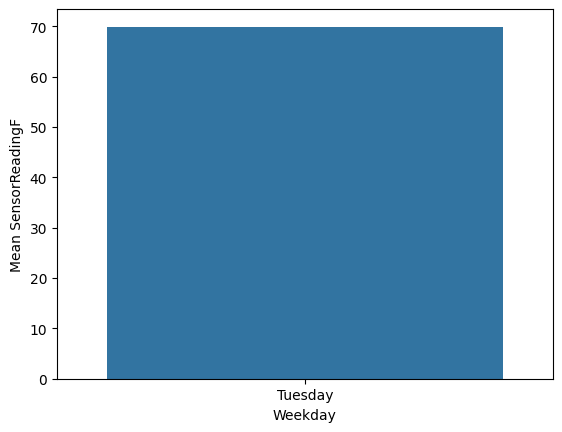

In [8]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u ON 
        abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 AND 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week
""").df()

sns.barplot(x = 'Weekday', y = 'Mean SensorReadingF', data = data)

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

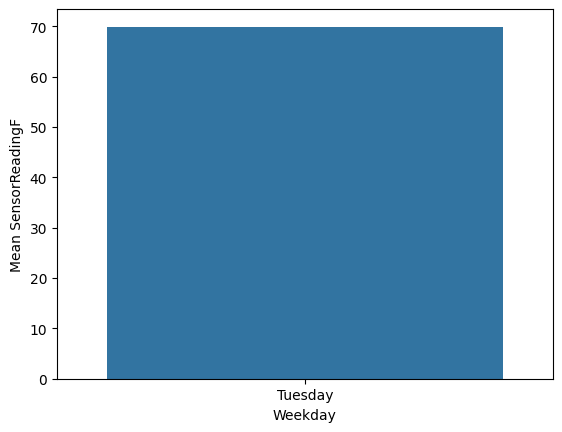

In [9]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week
""").df()

# need DISTINCT on utcs to prevent duplication.

sns.barplot(x = 'Weekday', y = 'Mean SensorReadingF', data = data)

In [10]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID_Coris) as 'Count of Devices'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('data/devices.parquet') AS d
        ON d.DeviceID_Coris = dr.DeviceID_Coris
    GROUP BY Building
    ORDER BY min(date)
""").df()

BinderException: Binder Error: Table "d" does not have a column named "DeviceID_Coris"

Candidate bindings: : "DeviceID"

In [ ]:
# Readings that differ from the Query UTC.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()